# IA 340 Mini Project
# Title: Analyzing NHL Shift Length vs. Player Performance
## Research question: How does minutes of ice time per shift relate to player performance? In other words, do better players take longer shifts on the ice, or shorter ones?

## Loading the data into a df and removing the many unnecessary columns/rows:

In [15]:
import warnings
warnings.simplefilter('ignore')

import pandas as pd

df = pd.read_csv('s3://ia340-2025-lab1/skaters.csv') # load the data from s3

pd.set_option('display.max_columns', None) # No maximum number of columns

df.head(10)

,playerId,season,name,team,position,situation,games_played,icetime,shifts,gameScore,onIce_xGoalsPercentage,offIce_xGoalsPercentage,onIce_corsiPercentage,offIce_corsiPercentage,onIce_fenwickPercentage,offIce_fenwickPercentage,iceTimeRank,I_F_xOnGoal,I_F_xGoals,I_F_xRebounds,I_F_xFreeze,I_F_xPlayStopped,I_F_xPlayContinuedInZone,I_F_xPlayContinuedOutsideZone,I_F_flurryAdjustedxGoals,I_F_scoreVenueAdjustedxGoals,I_F_flurryScoreVenueAdjustedxGoals,I_F_primaryAssists,I_F_secondaryAssists,I_F_shotsOnGoal,I_F_missedShots,I_F_blockedShotAttempts,I_F_shotAttempts,I_F_points,I_F_goals,I_F_rebounds,I_F_reboundGoals,I_F_freeze,I_F_playStopped,I_F_playContinuedInZone,I_F_playContinuedOutsideZone,I_F_savedShotsOnGoal,I_F_savedUnblockedShotAttempts,penalties,I_F_penalityMinutes,I_F_faceOffsWon,I_F_hits,I_F_takeaways,I_F_giveaways,I_F_lowDangerShots,I_F_mediumDangerShots,I_F_highDangerShots,I_F_lowDangerxGoals,I_F_mediumDangerxGoals,I_F_highDangerxGoals,I_F_lowDangerGoals,I_F_mediumDangerGoals,I_F_highDangerGoals,I_F_scoreAdjustedShotsAttempts,I_F_unblockedShotAttempts,I_F_scoreAdjustedUnblockedShotAttempts,I_F_dZoneGiveaways,I_F_xGoalsFromxReboundsOfShots,I_F_xGoalsFromActualReboundsOfShots,I_F_reboundxGoals,I_F_xGoals_with_earned_rebounds,I_F_xGoals_with_earned_rebounds_scoreAdjusted,I_F_xGoals_with_earned_rebounds_scoreFlurryAdjusted,I_F_shifts,I_F_oZoneShiftStarts,I_F_dZoneShiftStarts,I_F_neutralZoneShiftStarts,I_F_flyShiftStarts,I_F_oZoneShiftEnds,I_F_dZoneShiftEnds,I_F_neutralZoneShiftEnds,I_F_flyShiftEnds,faceoffsWon,faceoffsLost,timeOnBench,penalityMinutes,penalityMinutesDrawn,penaltiesDrawn,shotsBlockedByPlayer,OnIce_F_xOnGoal,OnIce_F_xGoals,OnIce_F_flurryAdjustedxGoals,OnIce_F_scoreVenueAdjustedxGoals,OnIce_F_flurryScoreVenueAdjustedxGoals,OnIce_F_shotsOnGoal,OnIce_F_missedShots,OnIce_F_blockedShotAttempts,OnIce_F_shotAttempts,OnIce_F_goals,OnIce_F_rebounds,OnIce_F_reboundGoals,OnIce_F_lowDangerShots,OnIce_F_mediumDangerShots,OnIce_F_highDangerShots,OnIce_F_lowDangerxGoals,OnIce_F_mediumDangerxGoals,OnIce_F_highDangerxGoals,OnIce_F_lowDangerGoals,OnIce_F_mediumDangerGoals,OnIce_F_highDangerGoals,OnIce_F_scoreAdjustedShotsAttempts,OnIce_F_unblockedShotAttempts,OnIce_F_scoreAdjustedUnblockedShotAttempts,OnIce_F_xGoalsFromxReboundsOfShots,OnIce_F_xGoalsFromActualReboundsOfShots,OnIce_F_reboundxGoals,OnIce_F_xGoals_with_earned_rebounds,OnIce_F_xGoals_with_earned_rebounds_scoreAdjusted,OnIce_F_xGoals_with_earned_rebounds_scoreFlurryAdjusted,OnIce_A_xOnGoal,OnIce_A_xGoals,OnIce_A_flurryAdjustedxGoals,OnIce_A_scoreVenueAdjustedxGoals,OnIce_A_flurryScoreVenueAdjustedxGoals,OnIce_A_shotsOnGoal,OnIce_A_missedShots,OnIce_A_blockedShotAttempts,OnIce_A_shotAttempts,OnIce_A_goals,OnIce_A_rebounds,OnIce_A_reboundGoals,OnIce_A_lowDangerShots,OnIce_A_mediumDangerShots,OnIce_A_highDangerShots,OnIce_A_lowDangerxGoals,OnIce_A_mediumDangerxGoals,OnIce_A_highDangerxGoals,OnIce_A_lowDangerGoals,OnIce_A_mediumDangerGoals,OnIce_A_highDangerGoals,OnIce_A_scoreAdjustedShotsAttempts,OnIce_A_unblockedShotAttempts,OnIce_A_scoreAdjustedUnblockedShotAttempts,OnIce_A_xGoalsFromxReboundsOfShots,OnIce_A_xGoalsFromActualReboundsOfShots,OnIce_A_reboundxGoals,OnIce_A_xGoals_with_earned_rebounds,OnIce_A_xGoals_with_earned_rebounds_scoreAdjusted,OnIce_A_xGoals_with_earned_rebounds_scoreFlurryAdjusted,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts,xGoalsForAfterShifts,xGoalsAgainstAfterShifts,corsiForAfterShifts,corsiAgainstAfterShifts,fenwickForAfterShifts,fenwickAgainstAfterShifts
0,8478047,2024,Michael Bunting,NSH,L,other,76,2237.0,37.0,26.19,0.37,0.42,0.65,0.45,0.64,0.47,228.0,13.06,3.93,1.21,2.77,0.65,6.69,2.75,2.54,3.93,2.54,1.0,1.0,9.0,9.0,3.0,21.0,3.0,1.0,3.0,0.0,2.0,0.0,10.0,2.0,8.0,17.0,0.0,0.0,0.0,2.0,0.0,0.0,8.0,3.0,7.0,0.25,0.41,3.27,0.0,1.0,0.0,21.00,18.0,18.00,0.0,0.38,1.07,1.47,2.84,2.84,2.42,37.0,11.0,0.0,0.0,26.0,6.0,3.0,18.0,10.0,0.0,0.0,3275.0,0.0,0.0,0.0,2.0,39.72,7.99,6.02,7.99,6.02,30.0,25.0,31.0,86.0,5.0,5.0,0.0,28.0,17.0

In [16]:
df.info()
df.describe()

df = df[df['situation'] == 'all'] #Getting rid of 5 on 4, 4 on 5, 5 on 5, and "other" situation entries in favor of all situations combined

df = df[['playerId', 'name', 'team', 'position', 'games_played', 'icetime', 'shifts', 'gameScore', 'onIce_xGoalsPercentage', 'onIce_corsiPercentage', 'I_F_primaryAssists', 'I_F_secondaryAssists', 'I_F_shotsOnGoal', 'I_F_goals', 'I_F_points', 'I_F_hits']]

df = df[df['games_played'] >= 10] # Only taking players with at least 10gp

df.head(10) #show the top 10 rows to verify I've properly imported and thinned the dataset to the columns I need

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Columns: 154 entries, playerId to fenwickAgainstAfterShifts
dtypes: float64(147), int64(3), object(4)
memory usage: 5.4+ MB


,playerId,name,team,position,games_played,icetime,shifts,gameScore,onIce_xGoalsPercentage,onIce_corsiPercentage,I_F_primaryAssists,I_F_secondaryAssists,I_F_shotsOnGoal,I_F_goals,I_F_points,I_F_hits
1,8478047,Michael Bunting,NSH,L,76,70819.0,1474.0,43.70,0.55,0.58,12.0,7.0,155.0,19.0,38.0,70.0
6,8480950,Ilya Lyubushkin,DAL,D,80,83457.0,1763.0,10.38,0.42,0.41,4.0,9.0,51.0,1.0,14.0,84.0
11,8477369,Carson Soucy,NYR,D,75,80618.0,1872.0,8.07,0.37,0.42,3.0,6.0,81.0,4.0,13.0,115.0
21,8477964,Ivan Barbashev,VGK,C,70,70553.0,1338.0,49.58,0.54,0.51,20.0,8.0,111.0,23.0,51.0,104.0
26,8481178,Egor Zamula,PHI,D,63,62455.0,1396.0,15.28,0.53,0.50,5.0,7.0,37.0,3.0,15.0,24.0
31,8484153,Leo Carlsson,ANA,C,76,74056.0,1474.0,35.19,0.51,0.53,11.0,13.0,114.0,20.0,44.0,24.0
36,8479353,Brett Howden,VGK,C,80,71342.0,1531.0,39.75,0.49,0.47,9.0,8.0,125.0,23.0,40.0,121.0
41,8474641,Adam Henrique,EDM,C,81,71170.0,1583.0,23.44,0.46,0.44,5.0,10.0,104.0,12.0,27.0,58.0
46,8478904,Steven Lorentz,TOR,C,80,50654.0,1265.0,17.46,0.42,0.42,5.0,6.0,76.0,8.0,19.0,199.0
51,8479772,Zack MacEwen,OTT,R,21,9779.0,271.0,5.13,0.54,0.53,0.0,1.0,26.0,2.0,3.0,49.0


# Dataset Documentation & Import/Cleaning Explanation:
## This dataset was fetched from moneypuck.com (https://moneypuck.com/stats.htm), a website for tracking NHL advanced player and team stats. The chosen stat sheet was all NHL skaters from the 2024-2025 season. This particular dataset and stat sheet was chosen due to its recency and abundance of reliable information all in one place. 

## Due to the complexity and amount of information available, I narrowed down the columns to be only those relevant to me: player descriptors (playerId, name, team, position), player icetime information (games_played, icetime, shifts), and a number of player performance descriptors and basic stats (the other columns shown above). Additionally, since the sheet contains a row for each on-ice situation (all situations, even strength, powerplays, penalty kills, other), I decided to get rid of all "situations" other than the one describing all "situations".

# Query + Cleaning note:
## There weren't any notable instances of missing/misformated data to fix or duplicates to remove, but I decided to only include skaters with a minimum of 10 games played for the sake of removing outliers.

# Process/Aggregate Explanation:

## Below, I create an "average shift length" variable in the dataframe to be able to easily visualize the data point, as it is one of my main focal points in my study.

In [ ]:
# Calculate average shift length (in seconds) per player
df['avg_shift_length'] = (df['icetime']) / df['shifts']  # icetime is in seconds

# Figure 1: Distribution of Average Shift Lengths in the NHL

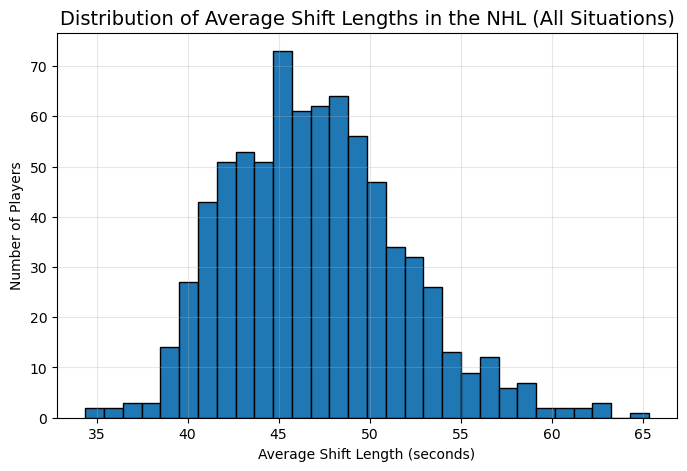

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['avg_shift_length'], bins=30, edgecolor='black')
plt.title('Distribution of Average Shift Lengths in the NHL', fontsize=14)
plt.xlabel('Average Shift Length (seconds)')
plt.ylabel('Number of Players')
plt.grid(alpha=0.3)
plt.show()

# Explanation:
## This histogram shows the distribution of average shift lengths for NHL players across all situations, limited to players with at least 10 games played. Most players take shifts between 40 and 50 seconds, with the peak around 45 seconds. This indicates that NHL coaches generally keep player shifts short to maintain high intensity and avoid fatigue. The small number of longer shifts (above 55 seconds) likely belong to star players or defensemen who stay on the ice during extended plays.

# Figure 2: Average Shift Length vs. Game Score

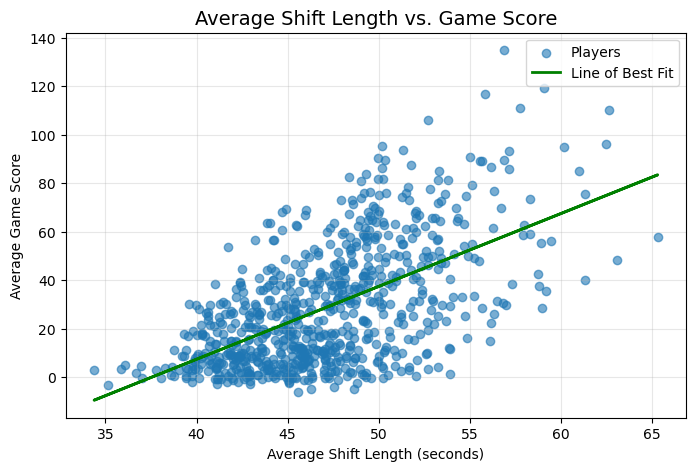

In [28]:
import numpy as np

x = df['avg_shift_length']
y = df['gameScore']

# Fit a first-degree polynomial (linear regression)
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.6, label='Players')
plt.plot(x, m*x + b, color='green', linewidth=2, label='Line of Best Fit')
plt.title('Average Shift Length vs. Game Score', fontsize=14)
plt.xlabel('Average Shift Length (seconds)')
plt.ylabel('Average Game Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Explanation:
## This scatter plot examines the relationship between a player’s average shift length and their average game score, a composite measure of individual performance. Each point represents one NHL player. The line of best fit suggests a positive correlation — players who take slightly longer shifts tend to have higher game scores on average. This trend implies that more effective or higher-impact players are trusted to stay on the ice longer, although there is still significant variation, meaning shift length alone does not fully determine performance.

# Figure 3: Average Shift Length vs. On-Ice Expected Goals% (xG%)

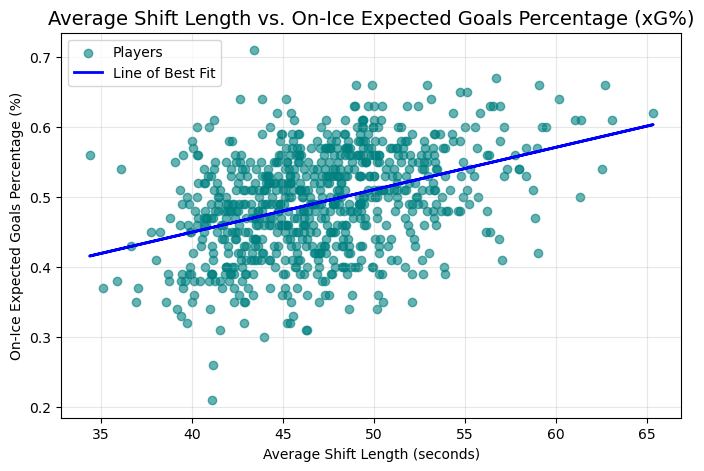

In [27]:
x = df['avg_shift_length']
y = df['onIce_xGoalsPercentage']

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.6, color='teal', label='Players')
plt.plot(x, m*x + b, color='blue', linewidth=2, label='Line of Best Fit')
plt.title('Average Shift Length vs. On-Ice Expected Goals Percentage (xG%)', fontsize=14)
plt.xlabel('Average Shift Length (seconds)')
plt.ylabel('On-Ice Expected Goals Percentage (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Explanation:
## This scatter plot examines how average shift length relates to a player’s on-ice expected goals percentage (xG%), which measures the share of quality scoring chances a team generates while that player is on the ice. The line of best fit shows a slight upward trend, suggesting that players who take longer shifts tend to be on the ice for a higher proportion of their team’s expected goals. However, the relationship is relatively weak and scattered, indicating that shift length alone does not strongly determine a player’s ability to drive offensive play — other factors such as team role, linemates, and situational deployment also contribute significantly.